# Particle Swarm Optimisation Using PySwarms

In [69]:
import numpy as np
import matplotlib.pyplot as plt
import pyswarms as ps
import pyswarms.backend.generators
from pyswarms.single import global_best
from pyswarms.utils.functions import single_obj as fx
from tests.optimizers.test_tolerance import n_particles, iterations

## Basic Optimisation

### Global Best PSO

***Parameters:***
- $C_1$: Cognitive Coefficient - strength of pull toward personal best
- $C_2$: Social Coefficient - strength of pull toward global best
- $\omega$: Inertia weight - controls momentum from previous velocity

In [89]:
%%time
options = {'c1':0.5,
           'c2':0.3,
           'w':0.9}

optimiser = ps.single.GlobalBestPSO(n_particles = 10, dimensions=2, options=options)

cost, pos = optimiser.optimize(fx.sphere, iters=1000)

2025-11-09 17:13:33,009 - pyswarms.single.global_best - INFO - Optimize for 1000 iters with {'c1': 0.5, 'c2': 0.3, 'w': 0.9}
pyswarms.single.global_best: 100%|██████████|1000/1000, best_cost=2.25e-43
2025-11-09 17:13:33,492 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 2.2465999878365538e-43, best pos: [4.18177529e-22 2.23131246e-22]


CPU times: total: 625 ms
Wall time: 482 ms


### Local Best PSO

***Parameters:***
- $k\in\mathbb{Z},\ k\le n$: Number of neighbours a particle can communicate with.
- $p\in\{1,2,3\}$: Type of neighbourhood topology: 1 - ring (default); 2 - random; 3 - nearest.

In [71]:
%%time
options = {'c1':0.5,
           'c2':0.3,
           'w':0.9,
           'k':2,
           'p':2}

optimiser = ps.single.LocalBestPSO(n_particles = 10, dimensions=2, options=options)

cost, pos = optimiser.optimize(fx.sphere, iters=1000)

2025-11-09 17:09:37,271 - pyswarms.single.local_best - INFO - Optimize for 1000 iters with {'c1': 0.5, 'c2': 0.3, 'w': 0.9, 'k': 2, 'p': 2}
pyswarms.single.local_best: 100%|██████████|1000/1000, best_cost=2e-42  
2025-11-09 17:09:37,902 - pyswarms.single.local_best - INFO - Optimization finished | best cost: 1.998923381775297e-42, best pos: [-1.40257981e-21 -1.78026026e-22]


CPU times: total: 781 ms
Wall time: 636 ms


### Optimising with bounds

In [72]:
max_bound = 5.12 * np.ones(2)
min_bound = -max_bound
bounds = (min_bound, max_bound)
bounds

(array([-5.12, -5.12]), array([5.12, 5.12]))

In [73]:
%%time
options = {'c1':0.5,
           'c2':0.3,
           'w':0.9}

optimiser = ps.single.GlobalBestPSO(n_particles = 10, dimensions=2, options=options, bounds=bounds)

cost, pos = optimiser.optimize(fx.rastrigin, iters=1000)

2025-11-09 17:09:37,995 - pyswarms.single.global_best - INFO - Optimize for 1000 iters with {'c1': 0.5, 'c2': 0.3, 'w': 0.9}
pyswarms.single.global_best: 100%|██████████|1000/1000, best_cost=0.995
2025-11-09 17:09:38,522 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 0.9949590570932898, best pos: [9.94958638e-01 5.96799436e-10]


CPU times: total: 625 ms
Wall time: 532 ms


### Using Arguments

In [74]:
def rosenbrock_with_args(x,a,b,c=0):
    f = (a - x[:, 0]) ** 2 + b * (x[:, 1] - x[:, 0] ** 2) ** 2 + c
    return f

In [75]:
x_max = 10 * np.ones(2)
x_min = -1* x_max
bounds = (x_min, x_max)
options = {'c1':0.5,
           'c2':0.3,
           'w':0.9}
optimiser = ps.single.GlobalBestPSO(n_particles = 10, dimensions=2, options=options, bounds=bounds)

cost, pos = optimiser.optimize(rosenbrock_with_args, iters=1000, a=1, b=100, c=0)


2025-11-09 17:09:38,567 - pyswarms.single.global_best - INFO - Optimize for 1000 iters with {'c1': 0.5, 'c2': 0.3, 'w': 0.9}
pyswarms.single.global_best: 100%|██████████|1000/1000, best_cost=9.53e-18
2025-11-09 17:09:39,076 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 9.534210890292564e-18, best pos: [1.         0.99999999]


## Writing Your Own Optimisation Loop

In [76]:
import pyswarms.backend as bck
from pyswarms.backend.topology import Star

### Native Global-Best PSO Implementation 

In [77]:
def native_gbest_pso():
    for i in range(iterations):
        for particle in swarm:
            if f(current_position[particle]) < f(personal_best[particle]):
                peronal_best[particle] = current_position[particle]
                
            if f(personal_best[particle]) < f(global_best):
                global_best = personal_best[particle]
            
            update_velocity()
            update_position()

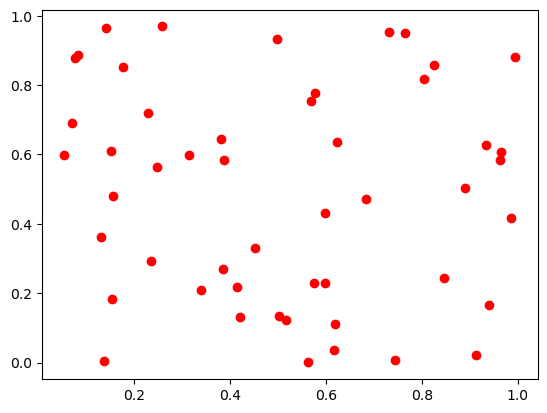

In [78]:
topology = Star()
options = {
    'c1': 0.6,
    'c2': 0.3,
    'w': 0.4
}
swarm = bck.create_swarm(n_particles=50, dimensions=2, options=options)

fig, ax = plt.subplots()
for pos in swarm.position:
    plt.scatter(pos[0], pos[1], color='red')

In [79]:
iterations = 100
f = fx.sphere
for i in range(iterations):
    swarm.current_cost = f(swarm.position)
    swarm.pbest_cost = f(swarm.pbest_pos)
    swarm.pbest_pos, swarm.pbest_cost = bck.compute_pbest(swarm)
    
    # for particle in swarm:
    if np.min(swarm.pbest_cost) < swarm.best_cost:
        swarm.best_pos, swarm.best_cost = topology.compute_gbest(swarm)

    if i%20==0:
        print('Iteration: {} | my_swarm.best_cost: {:.4f}'.format(i+1, swarm.best_cost))
        
    swarm.velocity = topology.compute_velocity(swarm)
    swarm.position = topology.compute_position(swarm)
    
print('The best cost found by our swarm is: {:.4f}'.format(swarm.best_cost))
print('The best position found by our swarm is: {}'.format(swarm.best_pos))

Iteration: 1 | my_swarm.best_cost: 0.0192
Iteration: 21 | my_swarm.best_cost: 0.0047
Iteration: 41 | my_swarm.best_cost: 0.0046
Iteration: 61 | my_swarm.best_cost: 0.0046
Iteration: 81 | my_swarm.best_cost: 0.0046
The best cost found by our swarm is: 0.0046
The best position found by our swarm is: [0.0673376  0.00697216]


In [80]:
optimiser = ps.single.GlobalBestPSO(n_particles=50, dimensions=2, options=options) # Reuse our previous options
optimiser.optimize(f, iters=100)

2025-11-09 17:09:39,465 - pyswarms.single.global_best - INFO - Optimize for 100 iters with {'c1': 0.6, 'c2': 0.3, 'w': 0.4}
pyswarms.single.global_best: 100%|██████████|100/100, best_cost=0.0165
2025-11-09 17:09:39,523 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 0.016515826316273345, best pos: [0.08439344 0.09692045]


(0.016515826316273345, array([0.08439344, 0.09692045]))

## Visualisation

In [81]:
from IPython.display import Image
from pyswarms.utils.plotters import (plot_cost_history, plot_contour, plot_surface)
from pyswarms.utils.plotters.formatters import Mesher
from pyswarms.utils.plotters.formatters import Designer

### Plotting Cost History

2025-11-09 17:09:39,668 - pyswarms.single.global_best - INFO - Optimize for 1000 iters with {'c1': 0.5, 'c2': 0.3, 'w': 0.9}
pyswarms.single.global_best: 100%|██████████|1000/1000, best_cost=1.63e-47
2025-11-09 17:09:40,162 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 1.6330173410596727e-47, best pos: [-2.06918439e-24 -3.47111644e-24]


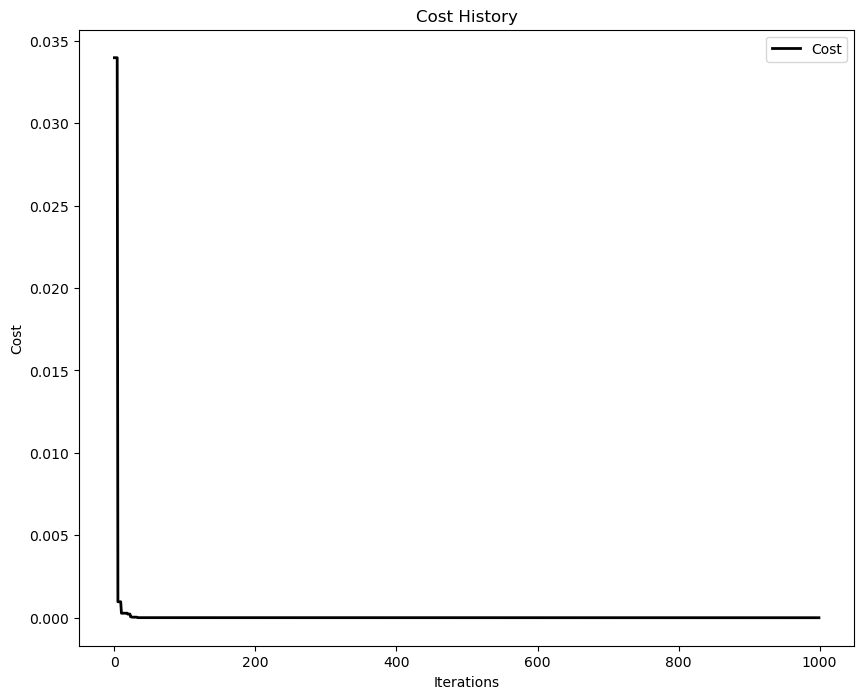

In [82]:
options = {'c1':0.5, 'c2':0.3, 'w':0.9}
optimizer = ps.single.GlobalBestPSO(n_particles=50, dimensions=2, options=options)
cost, pos = optimizer.optimize(fx.sphere, iters=1000)

plot_cost_history(cost_history=optimizer.cost_history)
plt.show()

### Animating Swarms

In [83]:
m = Mesher(func=fx.sphere)

#### 2D-Space

In [84]:
%%capture
# Make animation
animation = plot_contour(pos_history=optimizer.pos_history,
                         mesher=m,
                         mark=(0,0))

In [85]:
animation.save('plot0.gif', writer='imagemagick', fps=10)
Image(url='plot0.gif')

2025-11-09 17:09:41,686 - matplotlib.animation - WARNING - MovieWriter imagemagick unavailable; using Pillow instead.
2025-11-09 17:09:41,690 - matplotlib.animation - INFO - Animation.save using <class 'matplotlib.animation.PillowWriter'>


#### 3D-Space

In [86]:
pos_history_3d = m.compute_history_3d(optimizer.pos_history)
d = Designer(limits=[(-1,1), (-1,1), (-0.1,1)], label=['x-axis', 'y-axis', 'z-axis'])

In [87]:
%%capture
# Make animation
animation3d = plot_surface(pos_history=pos_history_3d, # Use the cost_history we computed
                           mesher=m, designer=d,       # Customizations
                           mark=(0,0,0))               # Mark minima

In [88]:
animation3d.save('plot1.gif', writer='imagemagick', fps=10)
Image(url='plot1.gif')

2025-11-09 17:11:08,244 - matplotlib.animation - WARNING - MovieWriter imagemagick unavailable; using Pillow instead.
2025-11-09 17:11:08,245 - matplotlib.animation - INFO - Animation.save using <class 'matplotlib.animation.PillowWriter'>
